In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("college_admission_clean.csv")

In [4]:
X = df.drop("admission_status", axis=1)

X = pd.get_dummies(X, drop_first=True)

y = df["admission_status"]

In [5]:
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# Train model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [7]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
2,high_school_gpa,0.177359
3,sat_score,0.127813
15,interview_score,0.077798
13,essay_score,0.070193
14,recommendation_score,0.066076
1,family_income,0.058296
8,volunteer_hours,0.057424
5,attendance_rate,0.053389
11,social_media_hours,0.052121
4,act_score,0.044242


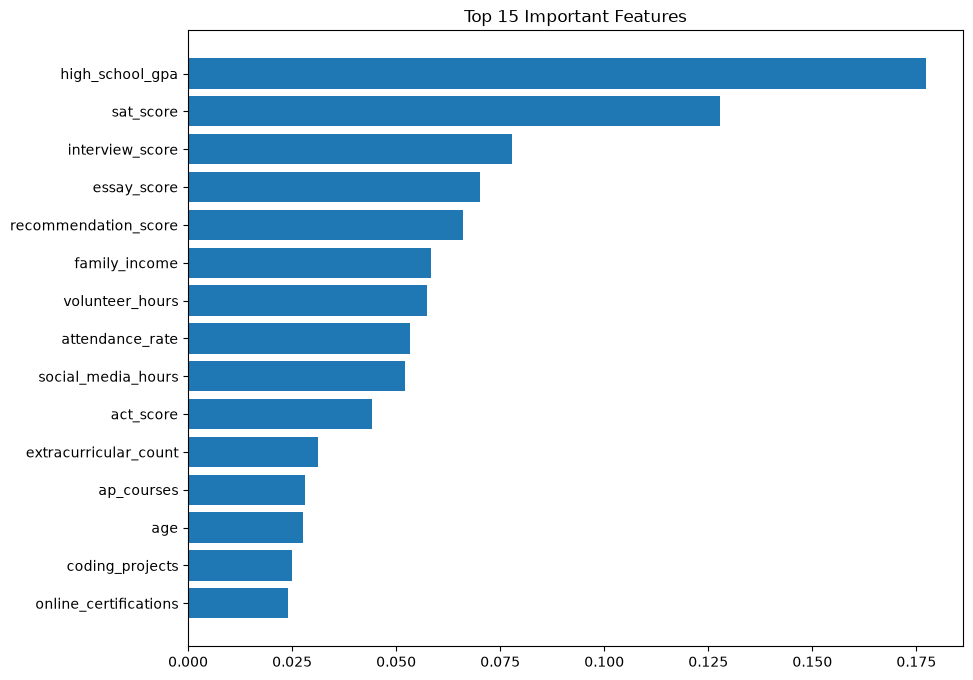

In [8]:
# Visualization
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [9]:
# GPA Bands
df["GPA Band"] = pd.cut(
    df["high_school_gpa"],
    bins=[0,3,3.5,3.8,4],
    labels=[
        "Average",
        "Good",
        "Very Good",
        "Excellent"
    ]
)

In [10]:
# Admission Rate
gpa_summary = (
    df.groupby("GPA Band", observed=False)["admission_status"]
      .agg(["count", "sum"])
      .reset_index()
)

gpa_summary["Admission Rate"] = (
    gpa_summary["sum"] /
    gpa_summary["count"] * 100
)

gpa_summary

,GPA Band,count,sum,Admission Rate
0,Average,121546,92623,76.204071
1,Good,133605,123187,92.202388
2,Very Good,55289,53668,97.068133
3,Excellent,39560,39091,98.814459


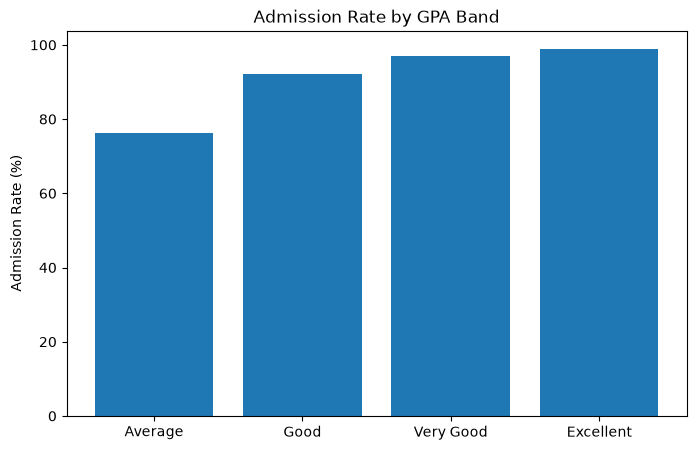

In [11]:
# Visualization
plt.figure(figsize=(8,5))

plt.bar(
    gpa_summary["GPA Band"],
    gpa_summary["Admission Rate"]
)

plt.title("Admission Rate by GPA Band")

plt.ylabel("Admission Rate (%)")

plt.show()

In [12]:
# Student Segmentation
conditions = [

(df["high_school_gpa"]>=3.8)
&
(df["sat_score"]>=1400),

(df["high_school_gpa"]>=3.5),

(df["high_school_gpa"]>=3.0),

(df["high_school_gpa"]<3.0)

]

choices = [

"Outstanding",

"Strong",

"Average",

"Needs Improvement"

]

df["Student Segment"] = np.select(
conditions,
choices,
default="Average"
)

In [13]:
# Count
df["Student Segment"].value_counts()

Student Segment
Average              133860
Needs Improvement    118985
Strong                93630
Outstanding            3525
Name: count, dtype: int64

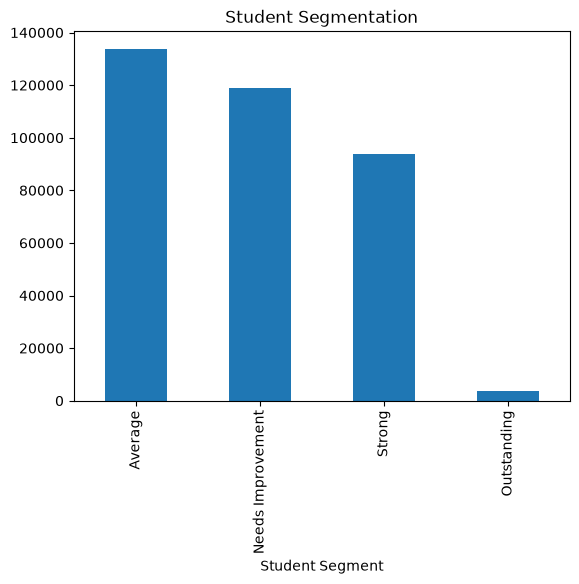

In [14]:
# Chart
df["Student Segment"]\
.value_counts()\
.plot(kind="bar")

plt.title("Student Segmentation")

plt.show()

In [15]:
# Admission Dashboard Table
dashboard = df.groupby(
"Student Segment",
observed=False
).agg({

"high_school_gpa":"mean",

"sat_score":"mean",

"interview_score":"mean",

"admission_status":"mean"

})

dashboard

,high_school_gpa,sat_score,interview_score,admission_status
Student Segment,,,,
Average,3.241282,1098.941282,72.768761,0.920574
Needs Improvement,2.662255,1099.722394,72.767708,0.759550
Outstanding,3.940043,1490.553759,72.583433,1.000000
Strong,3.755237,1084.289352,72.680638,0.976621


In [16]:
# Convert to %
dashboard["admission_status"] *=100

dashboard.rename(columns={
"admission_status":"Admission Rate"
}, inplace=True)

dashboard

,high_school_gpa,sat_score,interview_score,Admission Rate
Student Segment,,,,
Average,3.241282,1098.941282,72.768761,92.057373
Needs Improvement,2.662255,1099.722394,72.767708,75.954952
Outstanding,3.940043,1490.553759,72.583433,100.000000
Strong,3.755237,1084.289352,72.680638,97.662074


In [17]:
# Top States
top_states = (

df.groupby("state", observed=False)

["admission_status"]

.mean()

.sort_values(ascending=False)

.head(10)

*100

)

top_states

state
North Carolina    88.452439
New York          88.443114
Georgia           88.333618
Texas             88.238317
Florida           88.219366
Ohio              88.125430
Washington        88.111547
Illinois          87.965888
Virginia          87.894797
California        87.837451
Name: admission_status, dtype: float64

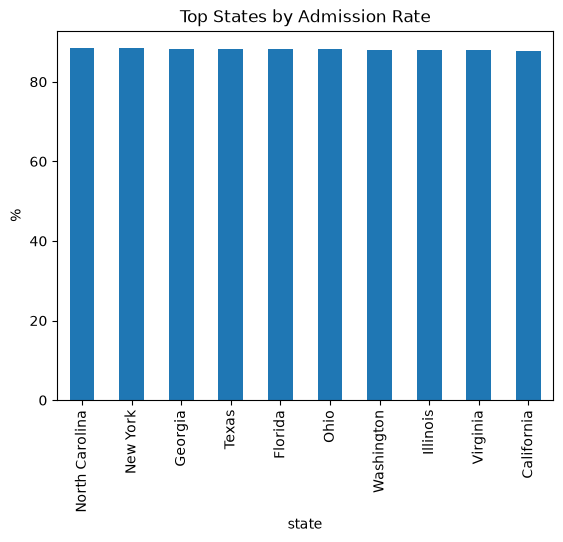

In [18]:
# Visualization
top_states.plot(kind="bar")

plt.title("Top States by Admission Rate")

plt.ylabel("%")

plt.show()

In [19]:
# Correlation Ranking
corr = df.corr(numeric_only=True)

ranking = corr["admission_status"]\
.sort_values(ascending=False)

ranking

admission_status         1.000000
high_school_gpa          0.318899
sat_score                0.232060
interview_score          0.123809
essay_score              0.101007
recommendation_score     0.083672
ap_courses               0.057452
leadership_positions     0.056201
extracurricular_count    0.053822
volunteer_hours          0.050687
online_certifications    0.038654
coding_projects          0.029272
attendance_rate          0.025684
act_score                0.003129
family_income            0.002366
social_media_hours       0.001771
age                      0.001292
Name: admission_status, dtype: float64

In [20]:
# Executive Summary
summary = pd.DataFrame({

"Metric":[

"Total Students",

"Admission Rate",

"Average GPA",

"Average SAT",

"Average Interview"

],

"Value":[

len(df),

round(df["admission_status"].mean()*100,2),

round(df["high_school_gpa"].mean(),2),

round(df["sat_score"].mean(),0),

round(df["interview_score"].mean(),2)

]

})

summary

,Metric,Value
0,Total Students,350000.00
1,Admission Rate,88.16
2,Average GPA,3.19
3,Average SAT,1099.00
4,Average Interview,72.74
